# New York Restaurant Inspection
---

Team members:
- Hasan Abbas
- Ali Hasan

## Introduction 
New York City is home to more than 8.5 million residents and a vibrant food culture, with tens of thousands of restaurants, cafes, and food establishments serving diverse cuisines from around the world.

To ensure food safety and public health, the NYC Department of Health and Mental Hygiene (DOHMH) conducts regular inspections. Each inspection results in a score based on health code violations, which is then converted into a letter grade (A, B, or C) displayed publicly at the establishment.

This project explores NYC food establishment inspection data from 2022 to 2024 to identify:

- Inspection trends over time
- Grade distribution across boroughs
- Top-performing cuisines by borough
- Connections between food safety grades, neighborhood districts, and external socioeconomic factors

The goal is to provide data-driven insights and recommendations for improving food safety outcomes across the city.

---

## Problem Statement
An investor is interested in entering the New York City restaurant market and wants to identify the best investment opportunities.

## Objectives:

1. Which cuisine types consistently achieve the highest food safety grades (Grade A).
2. In which boroughs or districts these top-performing cuisines are most successful.
3. By analyzing inspection trends, grade distributions, and external socioeconomic data (e.g., income levels by district), the investor can make an informed decision on where to open a restaurant and what cuisine to choose for the highest chance of success.

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import seaborn as sns
import geopandas as gpd

In [61]:
data = pd.read_csv('newyork-restaurant-inspection.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', None)

In [3]:
data.info() # data type need to be change

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288932 entries, 0 to 288931
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  288932 non-null  int64  
 1   DBA                    288926 non-null  object 
 2   BORO                   288932 non-null  object 
 3   BUILDING               288430 non-null  object 
 4   STREET                 288929 non-null  object 
 5   ZIPCODE                286015 non-null  float64
 6   PHONE                  288926 non-null  object 
 7   CUISINE DESCRIPTION    285222 non-null  object 
 8   INSPECTION DATE        288932 non-null  object 
 9   ACTION                 285222 non-null  object 
 10  VIOLATION CODE         283067 non-null  object 
 11  VIOLATION DESCRIPTION  283067 non-null  object 
 12  CRITICAL FLAG          288932 non-null  object 
 13  SCORE                  272998 non-null  float64
 14  GRADE                  140915 non-nu

In [4]:
data.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,Location Point1
count,2.889320e+05,286015.000000,272998.000000,288519.000000,288519.000000,285218.000000,285219.000000,285219.000000,2.838110e+05,2.881320e+05,0.0
mean,4.794763e+07,10706.279852,24.823237,40.316426,-73.194185,254.819762,20.648695,29793.267454,2.581506e+06,2.475269e+09,NaN
std,3.823638e+06,595.066666,18.610783,4.072910,7.393704,130.352100,15.732016,31231.008903,1.353013e+06,1.337407e+09,NaN
min,3.007544e+07,8512.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00,NaN
25%,5.000138e+07,10023.000000,12.000000,40.685576,-73.988776,106.000000,4.000000,8000.000000,1.051474e+06,1.011150e+09,NaN
50%,5.008650e+07,11101.000000,21.000000,40.732431,-73.956325,302.000000,20.000000,17200.000000,3.021143e+06,3.007840e+09,NaN
75%,5.012436e+07,11231.000000,33.000000,40.761247,-73.894813,401.000000,34.000000,42300.000000,4.010271e+06,4.006120e+09,NaN
max,5.017672e+07,28217.000000,175.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09,NaN


In [5]:
data.isnull().sum()

CAMIS                         0
DBA                           6
BORO                          0
BUILDING                    502
STREET                        3
ZIPCODE                    2917
PHONE                         6
CUISINE DESCRIPTION        3710
INSPECTION DATE               0
ACTION                     3710
VIOLATION CODE             5865
VIOLATION DESCRIPTION      5865
CRITICAL FLAG                 0
SCORE                     15934
GRADE                    148017
GRADE DATE               155821
RECORD DATE                   0
INSPECTION TYPE            3710
Latitude                    413
Longitude                   413
Community Board            3714
Council District           3713
Census Tract               3713
BIN                        5121
BBL                         800
NTA                        3714
Location Point1          288932
dtype: int64

### Data Handling: 
__Cleaning, transforming, and combining data__

In [6]:
# Start by changing the data type
df = data.astype({
    'CAMIS': 'category'
    ,'DBA': 'string'
    ,'BORO': 'category'
    ,'CUISINE DESCRIPTION': 'category'
    ,'INSPECTION DATE': 'datetime64[ns]'
    ,'ACTION': 'category'
    ,'VIOLATION CODE': 'category'
    ,'VIOLATION DESCRIPTION': 'category'
    ,'CRITICAL FLAG': 'category'
    ,'SCORE': 'Int64'
    ,'GRADE': 'category'
    ,'GRADE DATE': 'datetime64[ns]'
    ,'INSPECTION TYPE': 'category'
    ,'Latitude':'float32'
    ,'Longitude':'float32'
    ,'Community Board': 'category'
    ,'Census Tract': 'category'
})

In [7]:
# Droping un wanted coulmns:
df.drop(columns=["BIN","BBL", "NTA", "Location Point1", 'BUILDING', 'STREET', 'PHONE', 'ZIPCODE','RECORD DATE'], inplace=True)

In [8]:
#renaming the values
grade = {"A":"Grade A", "B":"Grade B", "C":"Grade C", "Z":"Grade Pending",
         "P":"Grade Pending issued on re-opening following an initial inspection that resulted in a closure"}
df['GRADE'] = df['GRADE'].map(grade)
df['GRADE'] = df['GRADE'].astype("category")

In [9]:
#replace Inspection dates of 1/1/1900 to blank
df['INSPECTION DATE'] = df['INSPECTION DATE'].replace("1900-01-01","")

In [10]:
# New coulmn to set if Inspected or not
df['Inspected?'] = df['INSPECTION DATE'].notna()

In [11]:
# Create a main cuisine. 
main_list = {
    "Asian (East & Southeast)": ["Chinese", "Japanese", "Thai", "Korean", "Filipino", "Indonesian", "Southeast Asian", "Chinese/Japanese", 
                                 "Chinese/Cuban", "Asian/Asian Fusion"]
    ,"Middle East & North Africa": ["Middle Eastern", "Turkish", "Egyptian", "Iranian", "Moroccan", "Lebanese", "Afghan", "Armenian"]
    ,"European": ["Italian", "Greek", "Spanish", "French", "German", "Portuguese", "Irish", "Russian", "Polish", "Scandinavian", "Czech", 
                  "Basque", "Eastern European", "English", "Continental", "New French"]
    ,"North American": ["American", "New American", "Californian", "Tex-Mex", "Barbecue", "Soul Food", "Creole", "Creole/Cajun", "Southwestern", 
                        "Steakhouse", "Cajun", "Hotdogs", "Hamburgers", "Sandwiches", "Hotdogs/Pretzels"]
    ,"Latin & Caribbean": ["Caribbean", "Latin American", "Mexican", "Peruvian", "Brazilian", "Chilean", "Hawaiian", "Chimichurri"]
    ,"African": ["African", "Ethiopian"]
    ,"Dietary & Fusion": ["Vegan", "Vegetarian", "Jewish/Kosher", "Fusion"]
    ,"Specialty & Light Meals": ["Pizza", "Seafood", "Chicken", "Soups", "Salads", "Sandwiches/Salads/Mixed Buffet", "Soups/Salads/Sandwiches", 
                                 "Tapas", "Fruits/Vegetables", "Mediterranean", "Australian"]
    ,"Baked Goods & Desserts": ["Bakery Products/Desserts", "Frozen Desserts", "Donuts", "Bagels/Pretzels", "Pancakes/Waffles", 
                                "Nuts/Confectionary"]
    ,"Beverages": ["Coffee/Tea", "Juice, Smoothies, Fruit Salads", "Bottled Beverages"]
    ,"Haute Cuisine": ["Haute Cuisine"]
    ,"Other": ["Other", "Not Listed/Not Applicable"]
}

def main_cuisine(cuisine):
    for main, cuisines in main_list.items():
        if cuisine in cuisines:
            return main
    return "Other"
# we will reserve the above 
df['Main Cuisine'] = df['CUISINE DESCRIPTION'].apply(main_cuisine)
df['Main Cuisine'] = df['Main Cuisine'].fillna("Other")
df['Main Cuisine'] = df['Main Cuisine'].astype("category")

In [12]:
df['CUISINE DESCRIPTION'].isnull().sum()

3710

In [13]:
df['Main Cuisine'].unique()

['Other', 'Asian (East & Southeast)', 'European', 'North American', 'Latin & Caribbean', ..., 'African', 'Baked Goods & Desserts', 'Dietary & Fusion', 'Middle East & North Africa', 'Haute Cuisine']
Length: 12
Categories (12, object): ['African', 'Asian (East & Southeast)', 'Baked Goods & Desserts', 'Beverages', ..., 'Middle East & North Africa', 'North American', 'Other', 'Specialty & Light Meals']

In [14]:
#Rename all columns:
df.rename(columns={
    'CAMIS': 'ID' #Restaurant ID
    ,'DBA': 'Name'
    ,'BORO': 'Borough'
    ,'CUISINE DESCRIPTION': 'Cuisine'
    ,'INSPECTION DATE': 'Inspection Date'
    ,'ACTION': 'Inspection Action'
    ,'VIOLATION CODE': 'Violation Code'
    ,'VIOLATION DESCRIPTION': 'Violation Description'
    ,'CRITICAL FLAG': 'Critical Flag'
    ,'SCORE': 'Score'
    ,'GRADE': 'Grade'
    ,'GRADE DATE': 'Grade Date'
    ,'RECORD DATE': 'Record Date'
    ,'INSPECTION TYPE': 'Inspection Type'
}, inplace= True)

In [15]:
df = df[df['Name'].notna()]

In [16]:
(df['Inspection Date'].dt.year).value_counts()

Inspection Date
2024.0    87974
2023.0    68414
2025.0    67666
2022.0    53912
2021.0     4581
2019.0      904
2018.0      668
2017.0      456
2020.0      400
2016.0      229
2015.0       18
Name: count, dtype: int64

In [17]:
df.describe(include='all')

,ID,Name,Borough,Cuisine,Inspection Date,Inspection Action,Violation Code,Violation Description,Critical Flag,Score,Grade,Grade Date,Inspection Type,Latitude,Longitude,Community Board,Council District,Census Tract,Inspected?,Main Cuisine
count,288926.0,288926,288926,285222,285222,285222,283067,283067,288926,272998.0,133111,133111,285222,288513.000000,288513.000000,285212.0,285213.000000,285213.0,288926,288926
unique,30353.0,24133,6,89,NaN,5,148,225,3,<NA>,5,NaN,34,NaN,NaN,68.0,NaN,1184.0,2,12
top,40365904.0,DUNKIN,Manhattan,American,NaN,Violations were cited in the following area(s).,10F,Non-food contact surface or equipment made of ...,Critical,<NA>,Grade A,NaN,Cycle Inspection / Initial Inspection,NaN,NaN,105.0,NaN,87100.0,True,North American
freq,74.0,3253,106874,45179,NaN,269803,40049,35790,153135,<NA>,95785,NaN,152386,NaN,NaN,22144.0,NaN,2746.0,285222,61886
mean,NaN,NaN,NaN,NaN,2023-12-30 16:38:20.995014400,NaN,NaN,NaN,NaN,24.823237,NaN,2024-01-01 23:17:53.122431232,NaN,40.316410,-73.194168,NaN,20.648694,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,2015-09-24 00:00:00,NaN,NaN,NaN,NaN,0.0,NaN,2015-09-24 00:00:00,NaN,0.000000,-74.249100,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,2023-02-15 00:00:00,NaN,NaN,NaN,NaN,12.0,NaN,2023-02-15 00:00:00,NaN,40.685566,-73.988777,NaN,4.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,2024-03-11 00:00:00,NaN,NaN,NaN,NaN,21.0,NaN,2024-03-13 00:00:00,NaN,40.732430,-73.956322,NaN,20.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,2024-12-16 00:00:00,NaN,NaN,NaN,NaN,33.0,NaN,2024-12-18 00:00:00,NaN,40.761246,-73.894814,NaN,34.000000,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,2025-09-18 00:00:00,NaN,NaN,NaN,NaN,175.0,NaN,2025-09-18 00:00:00,NaN,40.912823,0.000000,NaN,51.000000,NaN,NaN,NaN


### Analysis: 
__Answering the objectives through data analysis__



In [18]:
#spill data into 2 
df_Inspected = df[df['Inspected?'] == True ]
df_Not = df[df['Inspected?'] == False ]

In [19]:
df_Inspected['Graded?'] = df_Inspected['Grade'].notna()
df_Inspected['Scored?'] = df_Inspected['Score'].notna()

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\3860377134.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Inspected['Graded?'] = df_Inspected['Grade'].notna()
C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\3860377134.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Inspected['Scored?'] = df_Inspected['Score'].notna()


In [20]:
df_Inspected['Scored?'].value_counts()

Scored?
True     272998
False     12224
Name: count, dtype: int64

In [21]:
df_Inspected['Graded?'].value_counts()

Graded?
False    152111
True     133111
Name: count, dtype: int64

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\1347024922.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Inspected['Inspection Year'] = df_Inspected['Inspection Date'].dt.year
C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\1347024922.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Inspected['Inspection Year'] = df_Inspected['Inspection Year'].astype("category")


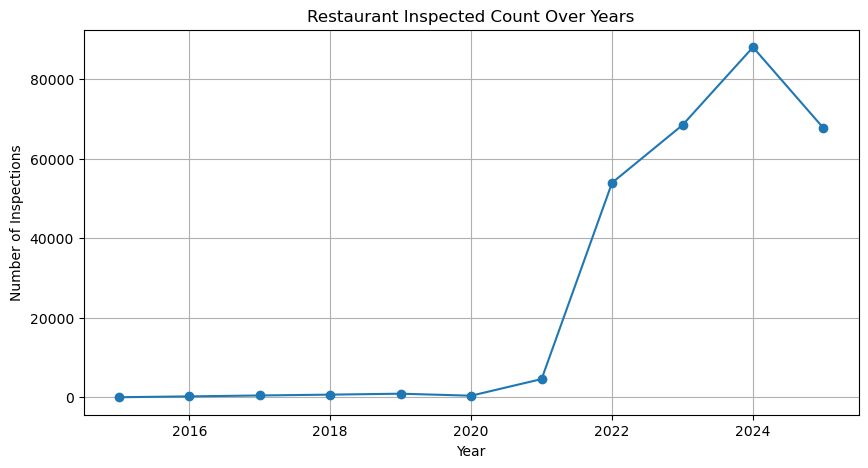

In [22]:
# Extract year
df_Inspected['Inspection Year'] = df_Inspected['Inspection Date'].dt.year
df_Inspected['Inspection Year'] = df_Inspected['Inspection Year'].astype("category")
# Count inspections per year per grade
Inspected_trend = df_Inspected["Inspection Year"].value_counts().sort_index().reset_index()
Inspected_trend.columns = ['Inspection Year', 'Count']

# Plot
plt.figure(figsize=(10,5))
plt.plot(Inspected_trend['Inspection Year'], Inspected_trend['Count'], marker='o')

plt.title("Restaurant Inspected Count Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Inspections")
plt.grid(True)
plt.show()

##### THERE is a jump after 2021 why? let's search
##### there is no reason.
##### so we will foucs on 4 years 2022-2025

In [23]:
df_Inspected = df_Inspected[~df_Inspected['Grade'].isin(["Grade Pending","Grade Pending issued on re-opening following an initial inspection that resulted in a closure"])]

In [24]:
df_Inspected['Inspection Year'] = df_Inspected['Inspection Date'].dt.year
df_Inspected = df_Inspected[df_Inspected['Inspection Year'].between(2022, 2025)]
df_Inspected['Inspection Year'] = df_Inspected['Inspection Date'].dt.year.astype('category')

In [25]:
grade = df_Inspected.groupby(['Borough', 'Grade'])['Grade'].value_counts().sort_values(ascending=False).reset_index()
grade.columns = ['Borough', 'Grade', 'Count']
grade = grade[grade['Count'] > 0]

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\4036805371.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade = df_Inspected.groupby(['Borough', 'Grade'])['Grade'].value_counts().sort_values(ascending=False).reset_index()


In [26]:
grades = {"Grade Pending issued on re-opening following an initial inspection that resulted in a closure":"Grade Pending issued on re-opening."}
grade['Grade'] = grade['Grade'].map(grades).fillna(grade['Grade'])
grade['Grade'] = grade['Grade'].astype("category")

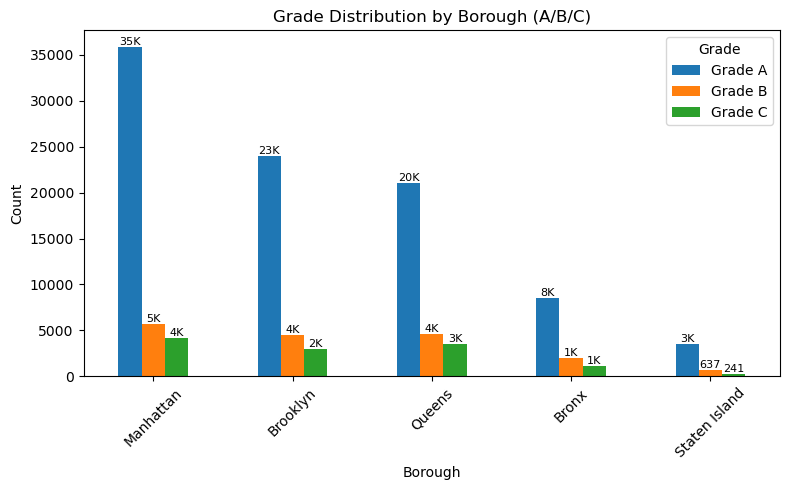

In [27]:
pivot = grade.pivot(index="Borough", columns="Grade", values="Count")

# Plot clustered bar chart
ax = pivot.plot(kind="bar", figsize=(8,5))

ax.set_title("Grade Distribution by Borough (A/B/C)")
ax.set_ylabel("Count")
ax.set_xlabel("Borough")
# Add value labels in K
for container in ax.containers:
    labels = [f"{int(v.get_height()/1000)}K" if v.get_height() >= 1000 else f"{int(v.get_height())}" for v in container]
    ax.bar_label(container, labels=labels, label_type="edge", fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
df_Inspected = df_Inspected[~df_Inspected['Grade'].isin(["Grade B","Grade C"])]

In [29]:
df_Inspected = df_Inspected[df_Inspected['Borough'].isin(["Manhattan", "Brooklyn", "Queens"])]

In [30]:
Borough = df_Inspected.groupby('Borough')['Main Cuisine'].value_counts(normalize=True).mul(100).rename("Percent").sort_values(ascending=False).reset_index()
Borough.columns = ['Borough', 'Main Cuisine', 'Percent']
Borough['Percent'] = round(Borough['Percent'], 2)
Borough = Borough[Borough['Percent']>0]

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\1172083016.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Borough = df_Inspected.groupby('Borough')['Main Cuisine'].value_counts(normalize=True).mul(100).rename("Percent").sort_values(ascending=False).reset_index()


In [31]:
# Take top 5:
Borough = Borough.groupby('Borough').head(5)

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\2665364121.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Borough = Borough.groupby('Borough').head(5)


In [32]:
Borough

,Borough,Main Cuisine,Percent
0,Manhattan,North American,27.60
1,Queens,Asian (East & Southeast),24.37
2,Brooklyn,North American,19.18
3,Queens,Latin & Caribbean,18.81
4,Brooklyn,Asian (East & Southeast),17.76
5,Manhattan,Asian (East & Southeast),17.45
6,Queens,North American,17.12
7,Brooklyn,Latin & Caribbean,14.20
8,Manhattan,Beverages,12.69
9,Brooklyn,Specialty & Light Meals,12.66


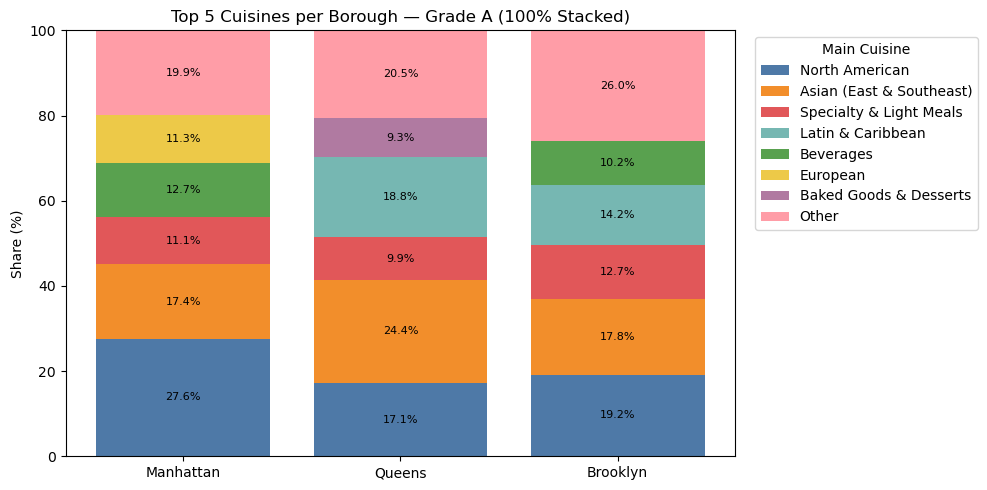

In [35]:
mat = (Borough.pivot(index='Borough', columns='Main Cuisine', values='Percent')
           .fillna(0))
# order cuisines by total across boroughs
mat = mat[mat.sum().sort_values(ascending=False).index]
mat100 = mat.copy()
colors = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
    "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AB"
]
other = (100 - mat100.sum(axis=1)).clip(lower=0)
mat100["Other"] = other
mat100 = mat100.div(mat100.sum(axis=1), axis=0).mul(100)
fig, ax = plt.subplots(figsize=(10,5))
bottom = np.zeros(len(mat100))
x = np.arange(len(mat100.index))
for i, col in enumerate(mat100.columns):
    vals = mat100[col].values
    rects = ax.bar(x, vals, bottom=bottom, label=col, color=colors[i % len(colors)])
    lbls = [f"{v:.1f}%" if v>0.5 else "" for v in vals]  # hide tiny labels
    ax.bar_label(rects, labels=lbls, label_type='center', fontsize=8)
    bottom += vals
ax.set_xticks(x, mat100.index, rotation=0)
ax.set_ylim(0, 100)
ax.set_ylabel("Share (%)")
ax.set_title("Top 5 Cuisines per Borough — Grade A (100% Stacked)")
ax.legend(title="Main Cuisine", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()

In [36]:
# top 2 in each:
Borough = Borough.groupby('Borough').head(2)

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\658025833.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Borough = Borough.groupby('Borough').head(2)


In [37]:
df_Inspected = df_Inspected[df_Inspected['Main Cuisine'].isin(['North American', 'Asian (East & Southeast)', 'Latin & Caribbean'])]

In [39]:
District = df_Inspected.groupby(['Borough','Council District'])['Main Cuisine'].value_counts(normalize=True).mul(100).rename("Percent").sort_values(ascending=False).reset_index()
District.columns = ['Borough', 'Council District', 'Main Cuisine','Percent']
District['Percent'] = round(District['Percent'], 2)
District = District[District['Percent']>0]

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\1462980991.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  District = df_Inspected.groupby(['Borough','Council District'])['Main Cuisine'].value_counts(normalize=True).mul(100).rename("Percent").sort_values(ascending=False).reset_index()


In [40]:
District

,Borough,Council District,Main Cuisine,Percent
0,Queens,20.0,Asian (East & Southeast),87.92
1,Queens,21.0,Latin & Caribbean,78.21
2,Brooklyn,43.0,Asian (East & Southeast),70.28
3,Manhattan,3.0,North American,62.47
4,Manhattan,4.0,North American,61.36
5,Queens,31.0,Latin & Caribbean,60.38
6,Brooklyn,41.0,Latin & Caribbean,59.50
7,Manhattan,6.0,North American,58.59
8,Brooklyn,33.0,North American,58.47
9,Queens,28.0,Latin & Caribbean,58.30


In [43]:
District = District.groupby('Borough').head(3)

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\3294287958.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  District = District.groupby('Borough').head(3)


In [48]:
District

,Borough,Council District,Main Cuisine,Percent
0,Queens,20.0,Asian (East & Southeast),87.92
1,Queens,21.0,Latin & Caribbean,78.21
2,Brooklyn,43.0,Asian (East & Southeast),70.28
3,Manhattan,3.0,North American,62.47
4,Manhattan,4.0,North American,61.36
5,Queens,31.0,Latin & Caribbean,60.38
6,Brooklyn,41.0,Latin & Caribbean,59.50
7,Manhattan,6.0,North American,58.59
8,Brooklyn,33.0,North American,58.47


C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\3293465860.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = District.pivot_table(


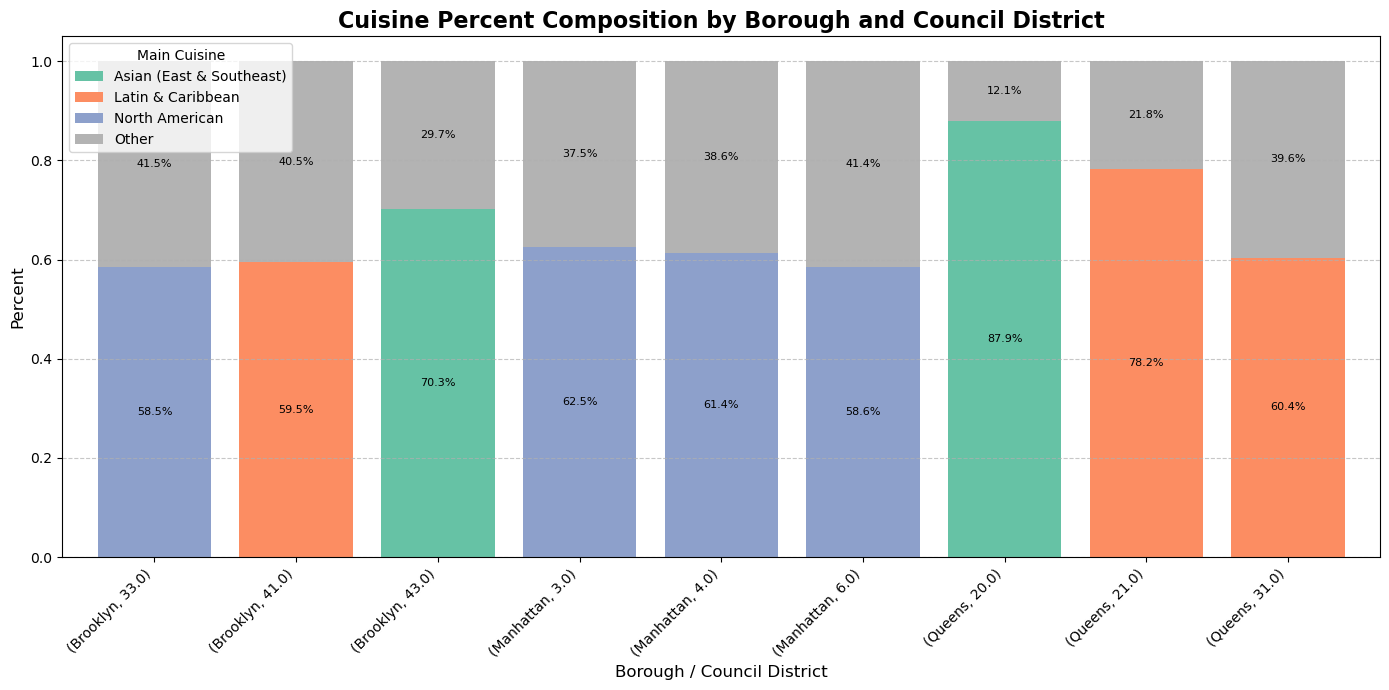

In [59]:
# Pivot table: MultiIndex
pivot = District.pivot_table(
    index=["Borough", "Council District"],
    columns="Main Cuisine",
    values="Percent",
    aggfunc='max'
)

# Fill missing values with 0
pivot = pivot.fillna(0)

# Calculate "Other" = 100% - sum of known cuisines per district
pivot['Other'] = 100 - pivot.sum(axis=1)

# Colors: cuisines + gray for Other
cuisines = pivot.columns.tolist()
colors = sns.color_palette("Set2", n_colors=len(cuisines)-1) + [(0.7,0.7,0.7)]  # gray for Other

# Plot 100% stacked bar chart
ax = pivot.div(pivot.sum(axis=1), axis=0).plot(
    kind='bar', 
    stacked=True, 
    figsize=(14,7), 
    color=colors,
    width=0.8
)

# Titles and labels
ax.set_title("Cuisine Percent Composition by Borough and Council District", fontsize=16, weight='bold')
ax.set_ylabel("Percent", fontsize=12)
ax.set_xlabel("Borough / Council District", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add percent labels inside bars
for container in ax.containers:
    labels = [f"{v.get_height()*100:.1f}%" if v.get_height() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [50]:
District['Council District'].unique()

array([20., 21., 43.,  3.,  4., 31., 41.,  6., 33.])

In [51]:
df_Inspected = df_Inspected[df_Inspected['Council District'].isin([20., 21., 43.,  3.,  4., 31., 41.,  6., 33.])]

In [63]:
Cuisine = df_Inspected.groupby(['Borough','Council District'])['Cuisine'].value_counts(normalize=True).mul(100).rename("Percent").sort_values(ascending=False).reset_index()
Cuisine.columns = ['Borough', 'District', 'Cuisine','Percent']
Cuisine['Percent'] = round(Cuisine['Percent'], 2)
Cuisine = Cuisine[Cuisine['Percent']>0]
#top 3
Cuisine = Cuisine.groupby('Borough').head(3)

Cuisine.sort_values(by='Borough')

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\657556014.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Cuisine = df_Inspected.groupby(['Borough','Council District'])['Cuisine'].value_counts(normalize=True).mul(100).rename("Percent").sort_values(ascending=False).reset_index()
C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\657556014.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Cuisine = Cuisine.groupby('Borough').head(3)


,Borough,District,Cuisine,Percent
1,Brooklyn,43.0,Chinese,57.70
2,Brooklyn,41.0,Caribbean,55.30
8,Brooklyn,33.0,American,46.66
4,Manhattan,3.0,American,49.72
6,Manhattan,4.0,American,48.08
7,Manhattan,6.0,American,47.92
0,Queens,20.0,Chinese,58.93
3,Queens,31.0,Caribbean,53.14
5,Queens,21.0,Latin American,49.66


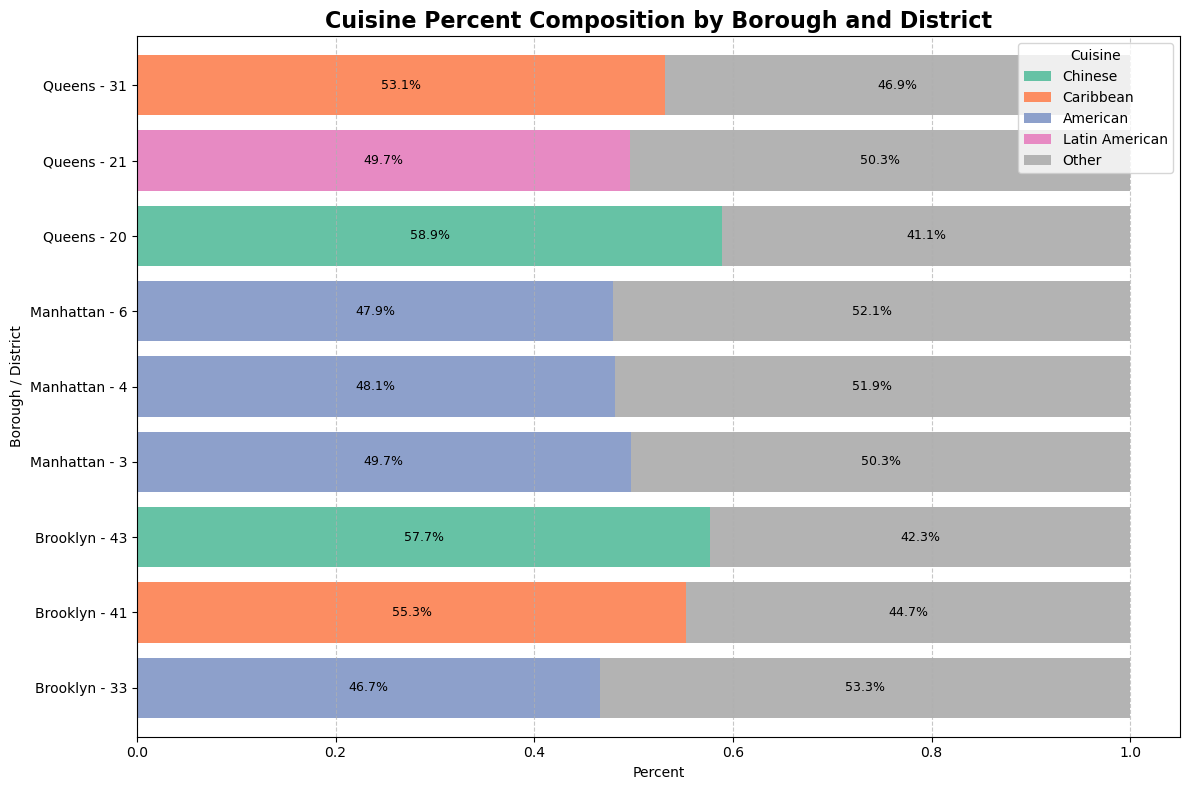

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy and create Borough_District column
Cuisine = Cuisine.copy()
Cuisine['Borough_District'] = Cuisine['Borough'].astype(str) + " - " + Cuisine['District'].astype(int).astype(str)

# Pivot for bar chart
pivot = Cuisine.pivot(index='Borough_District', columns='Cuisine', values='Percent').fillna(0)

# Add "Other" column
pivot['Other'] = 100 - pivot.sum(axis=1)

# Colors: cuisines + gray for Other
cuisines = pivot.columns.tolist()
colors = sns.color_palette("Set2", n_colors=len(cuisines)-1) + [(0.7, 0.7, 0.7)]  # gray for Other

# Plot horizontal 100% stacked bar chart
ax = pivot.div(pivot.sum(axis=1), axis=0).plot(
    kind='barh', 
    stacked=True, 
    figsize=(12,8), 
    color=colors,
    width=0.8
)

# Titles and labels
ax.set_title("Cuisine Percent Composition by Borough and District", fontsize=16, weight='bold')
ax.set_xlabel("Percent")
ax.set_ylabel("Borough / District")

# Gridlines
ax.xaxis.grid(True, linestyle='--', alpha=0.7)

# Add percent labels inside bars
for container in ax.containers:
    labels = [f"{v.get_width()*100:.1f}%" if v.get_width() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()


In [53]:
Cuisine['Cuisine'].unique()

['Chinese', 'Caribbean', 'American', 'Latin American']
Categories (89, object): ['Afghan', 'African', 'American', 'Armenian', ..., 'Thai', 'Turkish', 'Vegan', 'Vegetarian']

In [62]:
# Most Violation are for these type:
Violation = df[df['Cuisine'].isin(['Chinese', 'Caribbean', 'American', 'Latin American'])]
Violation = Violation.groupby('Cuisine')['Violation Description'].value_counts(normalize=True).mul(100).rename("Percent").sort_values(ascending=False).reset_index()
Violation.columns = ['Cuisine', 'Violation Description','Percent']
Violation['Percent'] = round(Cuisine['Percent'], 2)
Violation = Violation[Violation['Percent']>0]
Violation

C:\Users\hassa\AppData\Local\Temp\ipykernel_6520\3286275133.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Violation = Violation.groupby('Cuisine')['Violation Description'].value_counts(normalize=True).mul(100).rename("Percent").sort_values(ascending=False).reset_index()


,Cuisine,Violation Description,Percent
0,American,"Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.",58.93
1,Chinese,"Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.",57.70
2,Latin American,"Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.",55.30
3,Caribbean,"Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.",53.14
4,Caribbean,"Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.",49.72
5,Chinese,"Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.",49.66
6,American,"Food contact surface not properly washed, rinsed and sanitized after each use and following any activity when contamination may have occurred.",48.08
7,Latin American,"Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.",47.92
8,American,"Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.",46.66


## Key Operational Risks by Cuisine Type – Investor Alert

### American Cuisine

- Top Risk: 58.9% of inspections found non-food contact surfaces or equipment made of unacceptable materials, poorly maintained, or inaccessible for proper cleaning.
- Other Concern: 46.7% of establishments were not free of pests.
- Additional: 48.1% had issues with food contact surfaces not properly sanitized.

### Chinese Cuisine

- Top Risk: 57.7% of establishments failed to maintain non-food contact surfaces properly.
- Other Concern: 49.7% were not free of rodent or insect infestation risks.

### Latin American Cuisine

- Top Risk: 55.3% failed on non-food contact surface maintenance.
- Other Concern: 47.9% had conditions conducive to pests.

### Caribbean Cuisine

- Top Risk: 53.1% of establishments were not free of conditions conducive to rodents, insects, or other pests.

---

## Recommendations/Conclusion

Based on inspection data and risk analysis, we recommend considering investment in the following locations and cuisines, where operational standards appear manageable and growth potential is promising:

##### Queens:

    - Chinese in District 20

    - Caribbean in District 31

    - Latin American in District 21

##### Brooklyn:

    - Chinese in District 43

    - Caribbean in District 41

    - American in District 33

##### Manhattan:

    - American in District 3

    - American in District 4

    - American in District 6

##### Key Points:
- Diverse cuisines capture broad market demand.
- Strategic borough selection ensures high foot traffic and market potential.
- Focus on sites with better sanitation compliance to minimize operational risk.